In [1]:
import numpy as np
import pandas as pd

In [2]:
input = pd.read_csv('medical_data_logi.csv')

In [3]:
input

,age_years,bmi,fasting_glucose_mg_dl,systolic_bp_mmHg,total_chol_mg_dl,diabetes_label
0,42,26.3,117,106,223,0
1,51,33.0,106,129,228,0
2,73,30.8,71,137,220,1
3,56,27.6,180,112,172,1
4,45,26.8,149,122,225,1
...,...,...,...,...,...,...
155,47,25.8,107,125,166,1
156,44,19.7,143,158,129,1
157,66,29.4,153,147,144,0
158,51,23.7,105,162,265,0


In [4]:
print(input.columns)

Index(['age_years', 'bmi', 'fasting_glucose_mg_dl', 'systolic_bp_mmHg',
       'total_chol_mg_dl', 'diabetes_label'],
      dtype='object')


In [5]:
num_samples = len(input) 

rows, cols = input.shape
print(f"Total number of samples: {rows}")

Total number of samples: 160


In [6]:
print(input.describe())

numeric_cols = input.select_dtypes(include=['number'])
ranges = numeric_cols.max() - numeric_cols.min()

summary = pd.DataFrame({
    'Min': numeric_cols.min(),
    'Max': numeric_cols.max(),
    'Range': ranges
})
print(summary)

        age_years         bmi  fasting_glucose_mg_dl  systolic_bp_mmHg  \
count  160.000000  160.000000             160.000000        160.000000   
mean    48.562500   27.953125             114.312500        128.306250   
std     13.664759    4.277834              25.356871         17.245179   
min     25.000000   18.000000              70.000000         90.000000   
25%     37.750000   25.275000              96.750000        115.750000   
50%     48.000000   28.100000             117.000000        128.000000   
75%     59.000000   31.025000             130.250000        140.250000   
max     74.000000   39.300000             180.000000        168.000000   

       total_chol_mg_dl  diabetes_label  
count        160.000000      160.000000  
mean         202.050000        0.562500  
std           42.420892        0.497636  
min          120.000000        0.000000  
25%          172.750000        0.000000  
50%          199.500000        1.000000  
75%          234.500000        1.000000

In [7]:
min_glucose = input['fasting_glucose_mg_dl'].min()
max_glucose = input['fasting_glucose_mg_dl'].max()

input['fasting_glucose_mg_dl_nl'] = (input['fasting_glucose_mg_dl'] - min_glucose) / (max_glucose - min_glucose)
input['fasting_glucose_mg_dl_nl']

0      0.427273
1      0.327273
2      0.009091
3      1.000000
4      0.718182
         ...   
155    0.336364
156    0.663636
157    0.754545
158    0.318182
159    0.072727
Name: fasting_glucose_mg_dl_nl, Length: 160, dtype: float64

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

input_train, input_test = train_test_split(input, test_size=0.20, random_state=42)

print(f"Training samples: {len(input_train)}")
print(f"Testing samples: {len(input_test)}")

Training samples: 128
Testing samples: 32


In [13]:
X_train = input_train['fasting_glucose_mg_dl_nl'].values
y_train = input_train['diabetes_label'].values

w = 0.0
b = 0.0
learning_rate = 0.01
epochs = 1000
m = len(X_train)  

for i in range(epochs):
    z = w * X_train + b
    
    y_pred = 1 / (1 + np.exp(-z))
    
    dw = (1/m) * np.sum((y_pred - y_train) * X_train)
    
    db = (1/m) * np.sum(y_pred - y_train)
    
    w = w - learning_rate * dw
    b = b - learning_rate * db
    
    cost = -np.mean(y_train * np.log(y_pred) + (1 - y_train) * np.log(1 - y_pred))
    print(f"Epoch {i}: Cost = {cost:.4f}")

print(f"\nFinal Parameters: w = {w}, b = {b}")

Epoch 0: Cost = 0.6931
Epoch 1: Cost = 0.6931
Epoch 2: Cost = 0.6931
Epoch 3: Cost = 0.6931
Epoch 4: Cost = 0.6930
Epoch 5: Cost = 0.6930
Epoch 6: Cost = 0.6930
Epoch 7: Cost = 0.6929
Epoch 8: Cost = 0.6929
Epoch 9: Cost = 0.6929
Epoch 10: Cost = 0.6928
Epoch 11: Cost = 0.6928
Epoch 12: Cost = 0.6928
Epoch 13: Cost = 0.6928
Epoch 14: Cost = 0.6927
Epoch 15: Cost = 0.6927
Epoch 16: Cost = 0.6927
Epoch 17: Cost = 0.6926
Epoch 18: Cost = 0.6926
Epoch 19: Cost = 0.6926
Epoch 20: Cost = 0.6926
Epoch 21: Cost = 0.6925
Epoch 22: Cost = 0.6925
Epoch 23: Cost = 0.6925
Epoch 24: Cost = 0.6925
Epoch 25: Cost = 0.6924
Epoch 26: Cost = 0.6924
Epoch 27: Cost = 0.6924
Epoch 28: Cost = 0.6923
Epoch 29: Cost = 0.6923
Epoch 30: Cost = 0.6923
Epoch 31: Cost = 0.6923
Epoch 32: Cost = 0.6922
Epoch 33: Cost = 0.6922
Epoch 34: Cost = 0.6922
Epoch 35: Cost = 0.6922
Epoch 36: Cost = 0.6921
Epoch 37: Cost = 0.6921
Epoch 38: Cost = 0.6921
Epoch 39: Cost = 0.6921
Epoch 40: Cost = 0.6920
Epoch 41: Cost = 0.6920
Ep

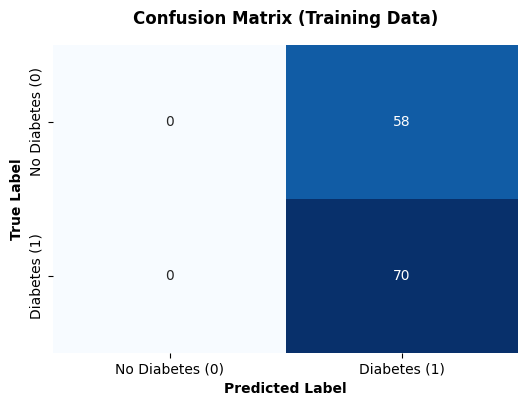

In [14]:
final_z = w * X_train + b
final_y_pred = 1 / (1 + np.exp(-final_z))

y_pred_class = (final_y_pred >= 0.5).astype(int)

cm = confusion_matrix(y_train, y_pred_class)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Diabetes (0)', 'Diabetes (1)'],
            yticklabels=['No Diabetes (0)', 'Diabetes (1)'])

plt.xlabel('Predicted Label', fontweight='bold')
plt.ylabel('True Label', fontweight='bold')
plt.title('Confusion Matrix (Training Data)', fontweight='bold', pad=15)
plt.show()

In [10]:
import numpy as np

# 1. Prepare the data
X_trainf = input_train[features].values
y_train = input_train['diabetes_label'].values.reshape(-1, 1) # Reshape for matrix math

# 2. Initialize parameters
m, n = X_trainf.shape  # m samples, n=5 features
wf = np.zeros((n, 1))  # wf must be a vector of 5 zeros
bf = 0.0
learning_rate = 0.01
epochs = 1000

for i in range(epochs):
    z = np.dot(X_trainf, wf) + bf
    
    y_predf = 1 / (1 + np.exp(-z))
    
    error = y_predf - y_train
    dwf = (1/m) * np.dot(X_trainf.T, error)
    dbf = (1/m) * np.sum(error)
    
    # Update Parameters
    wf = wf - learning_rate * dwf
    bf = bf - learning_rate * dbf
    
    if i % 100 == 0:
        cost = -np.mean(y_train * np.log(y_predf + 1e-15) + (1 - y_train) * np.log(1 - y_predf + 1e-15))
        print(f"Epoch {i}: Cost = {cost:.4f}")

print(f"\nFinal Weights:\n{wf}")
print(f"Final Bias: {bf}")

NameError: name 'features' is not defined